# Analisis de evaluacion manual - Parte 4

Este notebook carga `notas_manuales.csv`, reconstruye las metricas manuales por familia de metodo y pregunta, y genera visualizaciones para comparar el desempeno de los metodos en las preguntas 1 a 4, ademas de comparativas especificas entre `SPARSE` y `RRF` para todas las preguntas disponibles.

Tambien exporta una tabla LaTeX con la estructura `metodo | p1 | p2 | ... | p9`, dejando vacias las columnas donde aun no hay datos agregados.

In [7]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

CSV_PATH = Path('notas_manuales.csv')
OUTPUT_DIR = Path('output/parte4_notebook')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FAMILY_POSITIONS = {
    'DENSO': [3, 6, 9, 12],
    'GRAPH': [3, 6, 9, 12],
    'SPARSE': [3, 6, 9, 12, 15, 18, 21, 24, 27],
    'RFF': [3, 6, 9, 12, 15, 18, 21, 24, 27],
}

FAMILY_LABELS = {
    'DENSO': 'DENSO [COS]',
    'GRAPH': 'GRAPH',
    'SPARSE': 'SPARSE',
    'RFF': 'RRF [HNSW + SPARSE]',
}

QUESTION_LABELS = [f'P{i}' for i in range(1, 10)]


def detect_family(label: str) -> str | None:
    if label.startswith('DENSO'):
        return 'DENSO'
    if label.startswith('GRAPH'):
        return 'GRAPH'
    if label.startswith('SPARSE'):
        return 'SPARSE'
    if label.startswith('RFF'):
        return 'RFF'
    return None


records = []
with CSV_PATH.open(encoding='utf-8-sig', newline='') as file:
    reader = csv.reader(file)
    next(reader, None)
    next(reader, None)
    for row in reader:
        if len(row) < 2:
            continue
        label = row[1].strip()
        family = detect_family(label)
        if family is None:
            continue

        positions = FAMILY_POSITIONS[family]
        for question_index, score_pos in enumerate(positions, start=1):
            if score_pos >= len(row):
                continue
            raw_score = row[score_pos].strip()
            if not raw_score:
                continue
            try:
                score = float(raw_score.replace(',', '.'))
            except ValueError:
                continue

            similarity = None
            if score_pos + 1 < len(row) and row[score_pos + 1].strip():
                try:
                    similarity = float(row[score_pos + 1].replace(',', '.'))
                except ValueError:
                    similarity = None

            doc_id = row[score_pos + 2].strip() if score_pos + 2 < len(row) else ''
            records.append(
                {
                    'family': family,
                    'method_label': label,
                    'question': question_index,
                    'score': score,
                    'similarity': similarity,
                    'doc_id': doc_id,
                }
            )


df = pd.DataFrame(records)
score_summary = (
    df.groupby(['family', 'question'], as_index=False)['score']
    .mean()
    .sort_values(['family', 'question'])
)
coverage = (
    df.assign(present=1)
    .pivot_table(index='family', columns='question', values='present', aggfunc='sum', fill_value=0)
    .reindex(['DENSO', 'GRAPH', 'SPARSE', 'RFF'])
)
score_pivot = score_summary.pivot(index='family', columns='question', values='score')
method_global = (
    df.groupby('family', as_index=False)['score']
    .mean()
    .rename(columns={'score': 'mean_score'})
)

score_summary


,family,question,score
0,DENSO,1,6.30
1,DENSO,2,5.06
2,DENSO,3,5.74
3,DENSO,4,4.58
4,GRAPH,1,1.40
5,GRAPH,2,1.20
6,GRAPH,3,2.20
7,GRAPH,4,6.62
8,RFF,1,6.30
9,RFF,2,4.56


## Cálculo de métricas agregadas

En esta celda se consolidan los promedios por familia de método y pregunta. La tabla final deja vacías las preguntas para las que todavía no hay evaluación manual disponible en la familia correspondiente.

In [8]:
from IPython.display import display

summary_table = pd.DataFrame(index=['DENSO [COS]', 'GRAPH', 'SPARSE', 'RRF [HNSW + SPARSE]'], columns=[f'p{i}' for i in range(1, 10)], dtype=object)

for family, label in FAMILY_LABELS.items():
    family_scores = score_summary[score_summary['family'] == family].set_index('question')['score']
    for question in range(1, 10):
        value = family_scores.get(question)
        if pd.notna(value):
            summary_table.loc[label, f'p{question}'] = round(float(value), 2)

summary_table


,p1,p2,p3,p4,p5,p6,p7,p8,p9
DENSO [COS],6.3,5.06,5.74,4.58,NaN,NaN,NaN,NaN,NaN
GRAPH,1.4,1.2,2.2,6.62,NaN,NaN,NaN,NaN,NaN
SPARSE,6.34,4.4,5.5,4.68,6.5,6.86,5.6,2.0,4.0
RRF [HNSW + SPARSE],6.3,4.56,5.54,5.04,6.44,6.9,5.7,4.22,6.74


In [9]:
def format_cell(value):
    if value is None or pd.isna(value):
        return ''
    if isinstance(value, str) and not value.strip():
        return ''
    return f'{float(value):.2f}'

latex_lines = [
    '\\begin{table}[h]',
    '\\centering',
    '\\small',
    '\\renewcommand{\\arraystretch}{1.15}',
    '\\setlength{\\tabcolsep}{6pt}',
    '\\caption{Resumen de evaluación manual por método y pregunta}',
    '\\label{tab:resumen-parte4}',
    '\\resizebox{\\textwidth}{!}{%',
    '\\begin{tabular}{|l|' + 'c|' * 9 + '}',
    '\\hline',
    '\\textbf{Método} & \\textbf{$\\bar{X}_{P1}$} & \\textbf{$\\bar{X}_{P2}$} & \\textbf{$\\bar{X}_{P3}$} & \\textbf{$\\bar{X}_{P4}$} & \\textbf{$\\bar{X}_{P5}$} & \\textbf{$\\bar{X}_{P6}$} & \\textbf{$\\bar{X}_{P7}$} & \\textbf{$\\bar{X}_{P8}$} & \\textbf{$\\bar{X}_{P9}$} \\\\',
    '\\hline',
]

for method in summary_table.index:
    values = ' & '.join(format_cell(summary_table.loc[method, f'p{i}']) for i in range(1, 10))
    latex_lines.append(f'{method} & {values} \\\\')
    latex_lines.append('\\hline')

latex_lines.extend([
    '\\end{tabular}}',
    '\\end{table}',
])

latex_table = '\n'.join(latex_lines)
latex_output_path = OUTPUT_DIR / 'tabla_resumen_parte4.tex'
latex_output_path.write_text(latex_table, encoding='utf-8')
latex_table

'\\begin{table}[h]\n\\centering\n\\small\n\\renewcommand{\\arraystretch}{1.15}\n\\setlength{\\tabcolsep}{6pt}\n\\caption{Resumen de evaluación manual por método y pregunta}\n\\label{tab:resumen-parte4}\n\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|}\n\\hline\n\\textbf{Método} & \\textbf{$\\bar{X}_{P1}$} & \\textbf{$\\bar{X}_{P2}$} & \\textbf{$\\bar{X}_{P3}$} & \\textbf{$\\bar{X}_{P4}$} & \\textbf{$\\bar{X}_{P5}$} & \\textbf{$\\bar{X}_{P6}$} & \\textbf{$\\bar{X}_{P7}$} & \\textbf{$\\bar{X}_{P8}$} & \\textbf{$\\bar{X}_{P9}$} \\\\\n\\hline\nDENSO [COS] & 6.30 & 5.06 & 5.74 & 4.58 &  &  &  &  &  \\\\\n\\hline\nGRAPH & 1.40 & 1.20 & 2.20 & 6.62 &  &  &  &  &  \\\\\n\\hline\nSPARSE & 6.34 & 4.40 & 5.50 & 4.68 & 6.50 & 6.86 & 5.60 & 2.00 & 4.00 \\\\\n\\hline\nRRF [HNSW + SPARSE] & 6.30 & 4.56 & 5.54 & 5.04 & 6.44 & 6.90 & 5.70 & 4.22 & 6.74 \\\\\n\\hline\n\\end{tabular}}\n\\end{table}'

## Visualizaciones de métricas

Las figuras siguientes comparan los métodos con datos disponibles en P1-P4 y luego concentran el análisis en SPARSE vs RRF para todas las preguntas.

/var/folders/cw/q3kmrhcj05j6p8f0f9dpby7r0000gn/T/ipykernel_47345/3168140087.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=method_global_plot, x='family_label', y='mean_score', ax=axes[0, 1], palette='viridis')


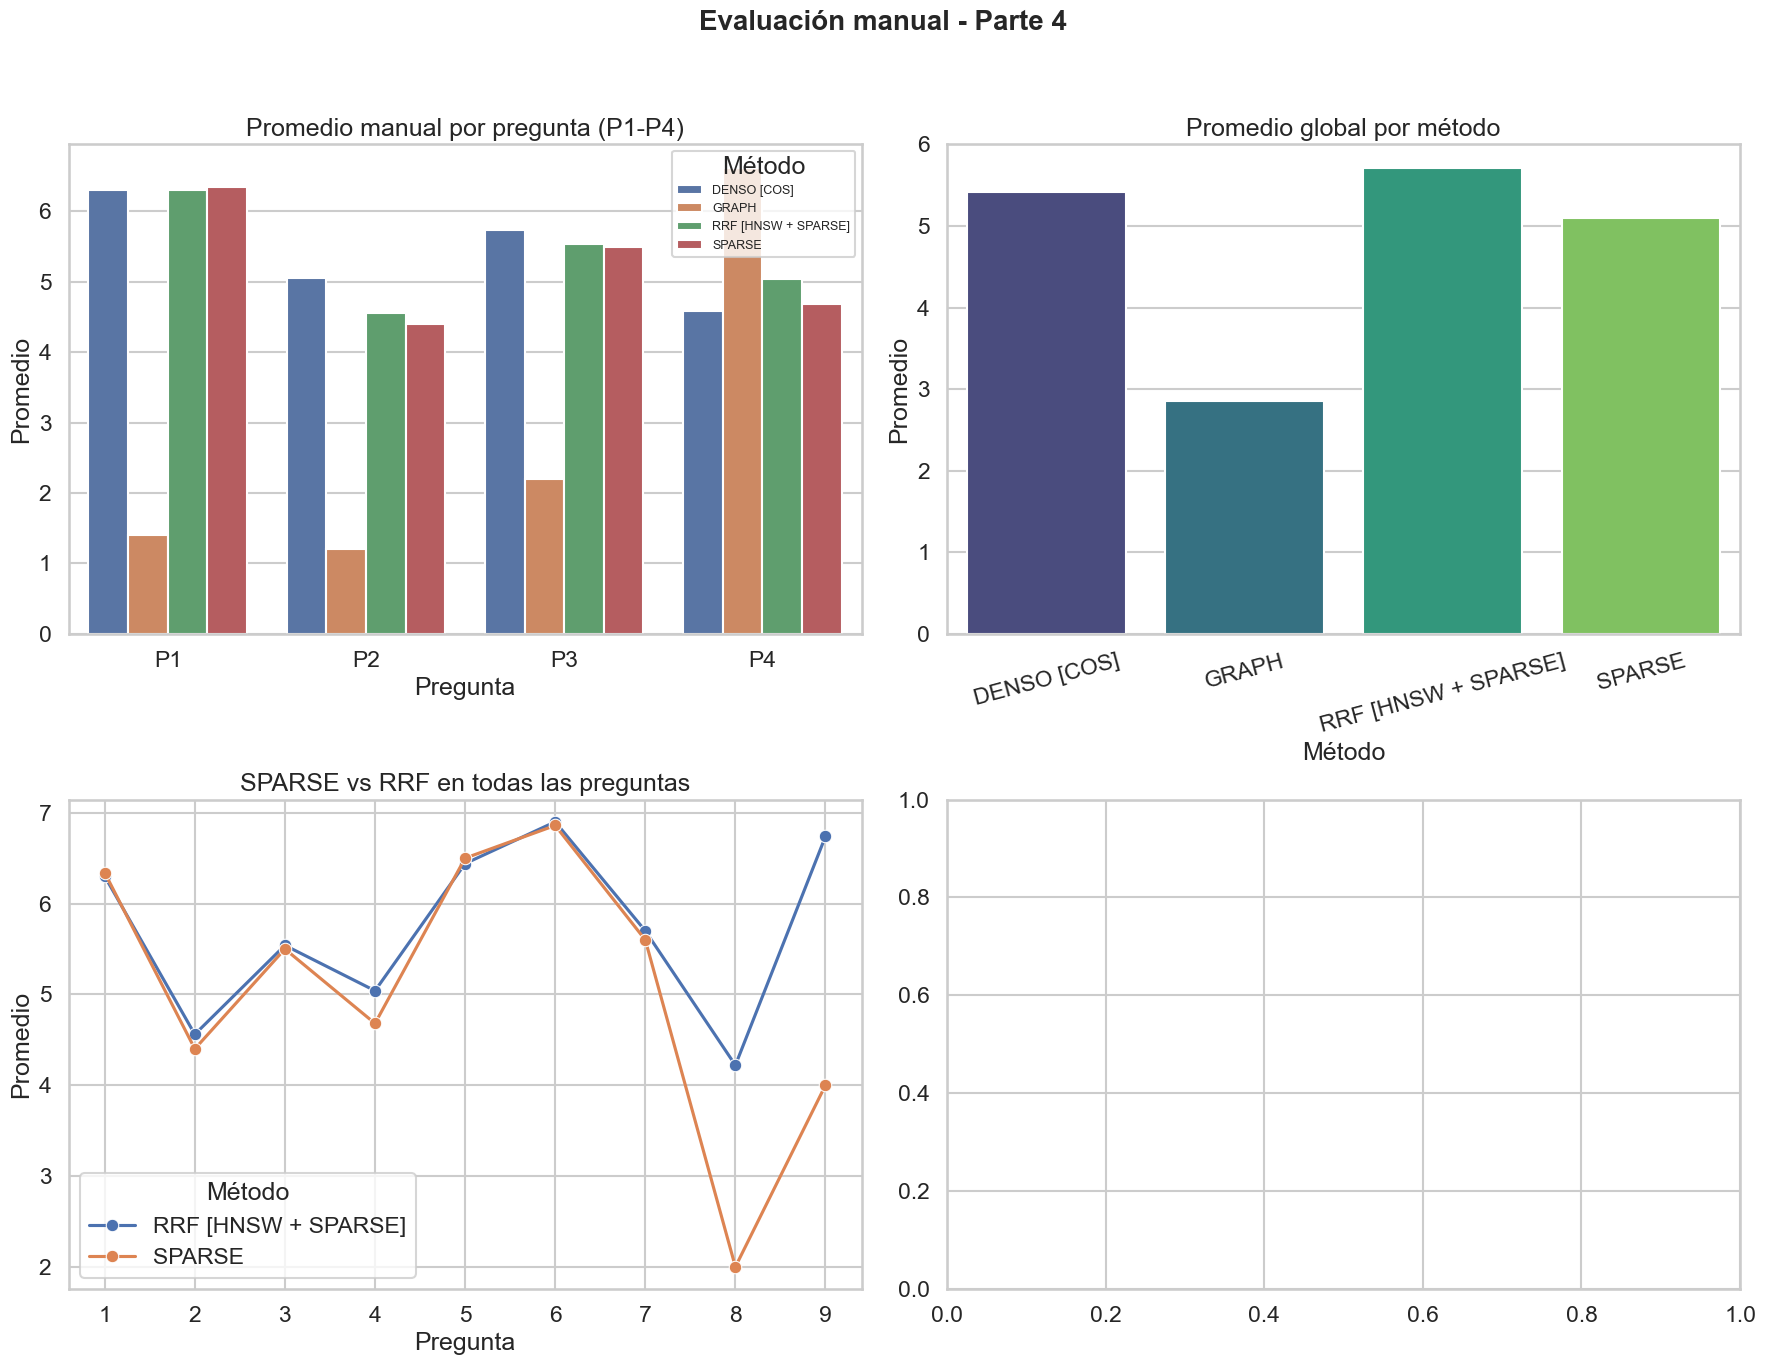

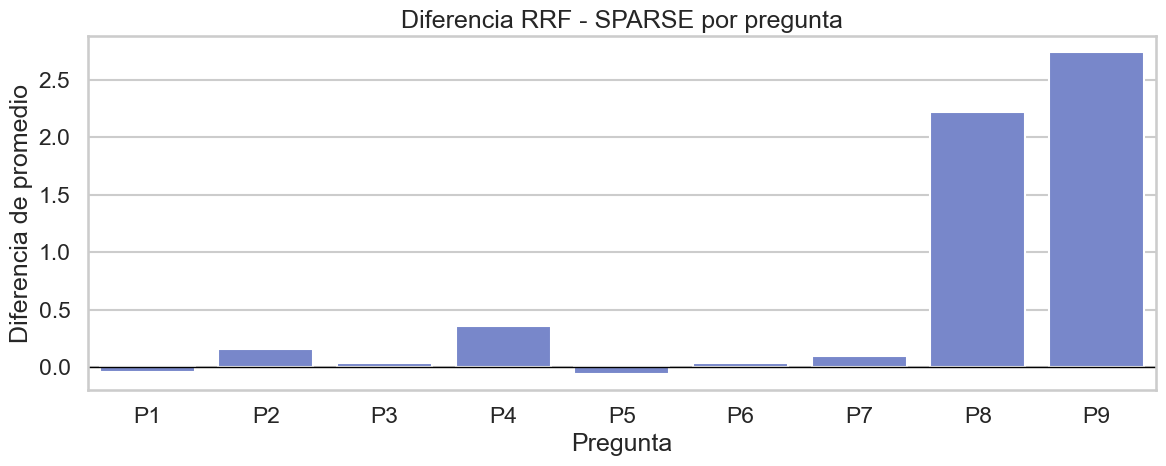

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Evaluación manual - Parte 4', fontsize=20, fontweight='bold')

# 1) Comparación p1-p4 entre todos los métodos
plot_p14 = score_summary[score_summary['question'].isin([1, 2, 3, 4])].copy()
plot_p14['question_label'] = plot_p14['question'].map(lambda x: f'P{x}')
plot_p14['family_label'] = plot_p14['family'].map(FAMILY_LABELS)
sns.barplot(data=plot_p14, x='question_label', y='score', hue='family_label', ax=axes[0, 0])
axes[0, 0].set_title('Promedio manual por pregunta (P1-P4)')
axes[0, 0].set_xlabel('Pregunta')
axes[0, 0].set_ylabel('Promedio')
axes[0, 0].legend(title='Método', fontsize=9)

# 2) Promedio global por método
method_global_plot = method_global.copy()
method_global_plot['family_label'] = method_global_plot['family'].map(FAMILY_LABELS)
sns.barplot(data=method_global_plot, x='family_label', y='mean_score', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Promedio global por método')
axes[0, 1].set_xlabel('Método')
axes[0, 1].set_ylabel('Promedio')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3) SPARSE vs RRF en todas las preguntas
sparse_rff = score_summary[score_summary['family'].isin(['SPARSE', 'RFF'])].copy()
sparse_rff['family_label'] = sparse_rff['family'].map(FAMILY_LABELS)
sns.lineplot(data=sparse_rff, x='question', y='score', hue='family_label', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('SPARSE vs RRF en todas las preguntas')
axes[1, 0].set_xlabel('Pregunta')
axes[1, 0].set_ylabel('Promedio')
axes[1, 0].set_xticks(range(1, 10))
axes[1, 0].legend(title='Método')



plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUTPUT_DIR / 'comparativa_general.png', dpi=180, bbox_inches='tight')
plt.show()

# 5) Diferencia RRF - SPARSE por pregunta
sparse_pivot = sparse_rff.pivot(index='question', columns='family', values='score')
delta = (sparse_pivot['RFF'] - sparse_pivot['SPARSE']).dropna()
plt.figure(figsize=(12, 5))
sns.barplot(x=delta.index, y=delta.values, color='#6B7FD7')
plt.axhline(0, color='black', linewidth=1)
plt.title('Diferencia RRF - SPARSE por pregunta')
plt.xlabel('Pregunta')
plt.ylabel('Diferencia de promedio')
plt.xticks(range(len(delta.index)), [f'P{i}' for i in delta.index])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'delta_rrf_sparse.png', dpi=180, bbox_inches='tight')
plt.show()


## Exportación de artefactos

Esta última sección deja en disco el bloque LaTeX y las figuras generadas para que puedan incluirse directamente en el informe.

In [11]:
exported_files = {
    'latex_table': latex_output_path,
    'comparative_plot': OUTPUT_DIR / 'comparativa_general.png',
    'delta_plot': OUTPUT_DIR / 'delta_rrf_sparse.png',
}

exported_files


{'latex_table': PosixPath('output/parte4_notebook/tabla_resumen_parte4.tex'),
 'comparative_plot': PosixPath('output/parte4_notebook/comparativa_general.png'),
 'delta_plot': PosixPath('output/parte4_notebook/delta_rrf_sparse.png')}

## Nuevas Métricas: Repetición de IDs, Boxplots y Similitud

/var/folders/cw/q3kmrhcj05j6p8f0f9dpby7r0000gn/T/ipykernel_47345/124335355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=doc_stats, x='family_label', y='nunique', ax=axes[0], palette='magma')
/var/folders/cw/q3kmrhcj05j6p8f0f9dpby7r0000gn/T/ipykernel_47345/124335355.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=doc_stats, x='family_label', y='ratio_repeticion', ax=axes[1], palette='magma')


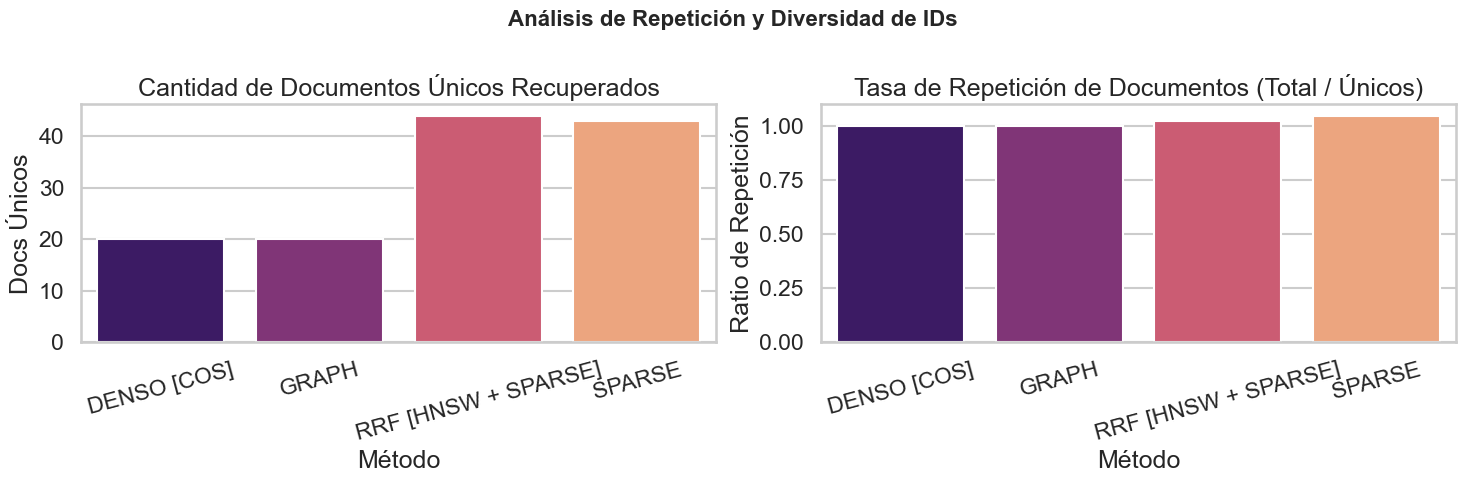

In [12]:
# Nueva Métrica: Diversidad de Documentos (ID Repetition)
# Contamos cuántos IDs únicos trae cada método y cuántas veces se repiten los documentos
doc_stats = df[df['doc_id'] != ''].groupby('family')['doc_id'].agg(['nunique', 'count']).reset_index()
doc_stats['ratio_repeticion'] = doc_stats['count'] / doc_stats['nunique']
doc_stats['family_label'] = doc_stats['family'].map(FAMILY_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Análisis de Repetición y Diversidad de IDs', fontsize=16, fontweight='bold')

sns.barplot(data=doc_stats, x='family_label', y='nunique', ax=axes[0], palette='magma')
axes[0].set_title('Cantidad de Documentos Únicos Recuperados')
axes[0].set_xlabel('Método')
axes[0].set_ylabel('Docs Únicos')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=doc_stats, x='family_label', y='ratio_repeticion', ax=axes[1], palette='magma')
axes[1].set_title('Tasa de Repetición de Documentos (Total / Únicos)')
axes[1].set_xlabel('Método')
axes[1].set_ylabel('Ratio de Repetición')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeticion_ids.png', dpi=180, bbox_inches='tight')
plt.show()


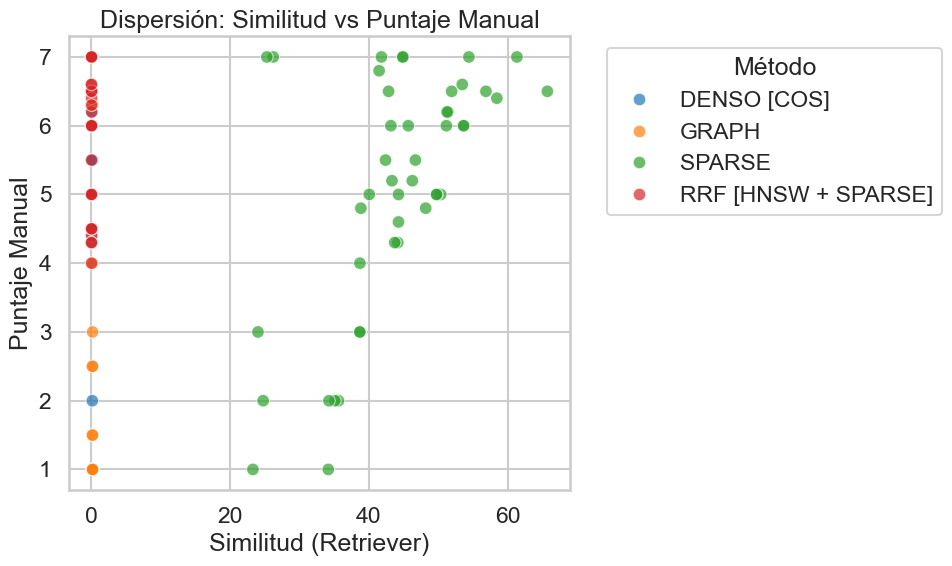

In [13]:
# Nueva Métrica: Correlación entre Score Manual y Similitud
# Si el modelo retorna similarity, vemos qué tan alineada está con el score humano
df_sim = df.dropna(subset=['similarity', 'score']).copy()
if not df_sim.empty:
    df_sim['family_label'] = df_sim['family'].map(FAMILY_LABELS)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_sim, x='similarity', y='score', hue='family_label', alpha=0.7, palette='tab10')
    plt.title('Dispersión: Similitud vs Puntaje Manual')
    plt.xlabel('Similitud (Retriever)')
    plt.ylabel('Puntaje Manual')
    plt.legend(title='Método', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'similitud_vs_score.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print("No hay suficientes datos con 'similarity' y 'score' simultáneamente.")


/var/folders/cw/q3kmrhcj05j6p8f0f9dpby7r0000gn/T/ipykernel_47345/4061578615.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='family_label', y='score', palette='Set2')


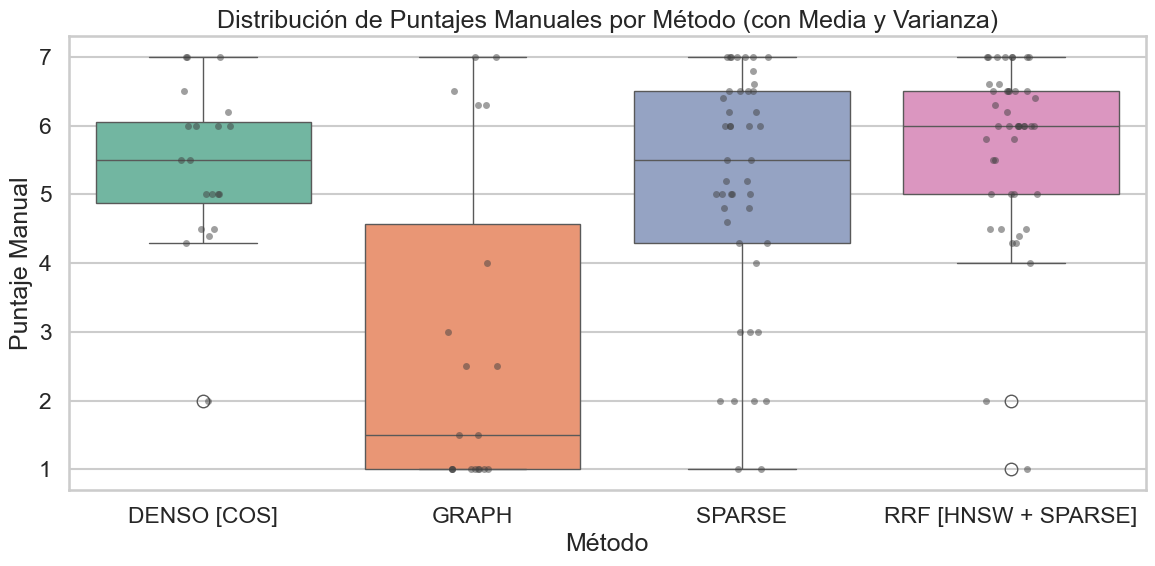

In [14]:
# Nueva Métrica: Distribución de Scores (Boxplot) para ver el promedio y varianza
plt.figure(figsize=(12, 6))
df_box = df.copy()
df_box['family_label'] = df_box['family'].map(FAMILY_LABELS)
sns.boxplot(data=df_box, x='family_label', y='score', palette='Set2')
sns.stripplot(data=df_box, x='family_label', y='score', color=".25", alpha=0.5)
plt.title('Distribución de Puntajes Manuales por Método (con Media y Varianza)')
plt.xlabel('Método')
plt.ylabel('Puntaje Manual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boxplot_scores.png', dpi=180, bbox_inches='tight')
plt.show()
